In [2]:
import numpy as np
import pandas as pd


In [10]:
df=pd.read_csv('/content/modified_placement_data.csv')

In [11]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [12]:
df.shape

(100, 3)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [14]:
import matplotlib.pyplot as plt

In [15]:
df['placement'].unique()

array(['Yes', 'No'], dtype=object)

In [16]:
df['cgpa'] = df['cgpa'].str.replace(',', '.')
df['cgpa'] = pd.to_numeric(df['cgpa'])

df['placement_num'] = df['placement'].map({'Yes':1, 'No':0})

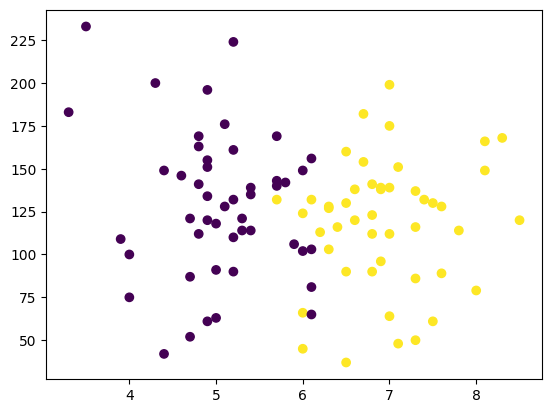

In [17]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['iq'], c=df['placement_num'])
plt.show()

In [18]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [19]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [20]:
Y

,placement_num
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [24]:
X_train

,cgpa,iq
76,4.9,155.0
80,4.9,196.0
92,5.2,110.0
23,4.7,87.0
19,5.2,132.0
...,...,...
72,7.3,116.0
39,4.6,146.0
40,4.9,134.0
52,7.0,175.0


In [25]:
Y_train

,placement_num
76,0
80,0
92,0
23,0
19,0
...,...
72,1
39,0
40,0
52,1


In [26]:
X_test

,cgpa,iq
12,5.4,139.0
27,6.0,124.0
41,5.4,114.0
26,7.0,199.0
91,NaN,158.0
1,5.9,106.0
50,3.5,233.0
69,8.5,120.0
21,7.1,151.0
37,8.1,149.0


In [33]:
df = df.dropna()

In [34]:
# Remove rows containing NaN values
df = df.dropna()

# Create features and target
X = df[['cgpa','iq']]
Y = df['placement_num']

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.1, random_state=42
)

In [35]:
df.isnull().sum()

,0
cgpa,0
iq,0
placement,0
placement_num,0


In [37]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)

In [38]:
X_train

array([[-1.34309392,  0.63476882],
       [ 0.43014768,  0.17629313],
       [-0.24537293,  1.11737481],
       [ 0.51458776,  0.36933553],
       [ 0.34570761, -0.16153106],
       [-0.16093285,  0.46585672],
       [-0.66757331,  0.22455373],
       [ 0.85234807, -0.25805226],
       [-0.92089354,  0.27281433],
       [-1.68085423, -1.15087335],
       [-0.66757331,  2.44454129],
       [-0.92089354,  1.7688929 ],
       [ 0.43014768, -2.06782473],
       [-1.76529431, -0.33044316],
       [-1.00533362,  0.97259301],
       [-0.49869316,  0.39346583],
       [ 0.0079473 , -1.36804604],
       [-2.10305461,  2.66171398],
       [ 0.85234807,  0.39346583],
       [ 2.11894922, -0.06500987],
       [ 0.0079473 , -1.87478233],
       [-1.34309392, -1.94717323],
       [ 0.93678814, -1.80239143],
       [-1.427534  ,  1.8654141 ],
       [ 1.1056683 , -0.16153106],
       [-0.24537293,  0.41759613],
       [-2.27193477,  1.45519901],
       [ 0.09238738, -1.00609155],
       [ 0.68346791,

In [39]:
X_test=sc.transform(X_test)

In [40]:
X_test

array([[ 0.26126753,  0.10390223],
       [-1.08977369, -0.86130975],
       [ 0.59902784,  0.75542032],
       [-1.00533362,  1.11737481],
       [ 0.68346791,  0.00738103],
       [ 0.0079473 ,  0.03151133],
       [-0.49869316, -0.20979166],
       [ 0.68346791,  0.44172642],
       [ 0.76790799,  0.36933553],
       [-0.58313323, -0.20979166]])

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
clf=LogisticRegression()

In [43]:
#model training
clf.fit(X_train,Y_train)

LogisticRegression()

In [46]:
Y_pred=clf.predict(X_test)

In [45]:
Y_test

,placement_num
70,1
23,0
74,1
75,0
0,1
27,1
41,0
43,1
11,1
46,0


In [47]:
from sklearn.metrics import accuracy_score

In [48]:
accuracy_score(Y_test,Y_pred)

0.9

In [49]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

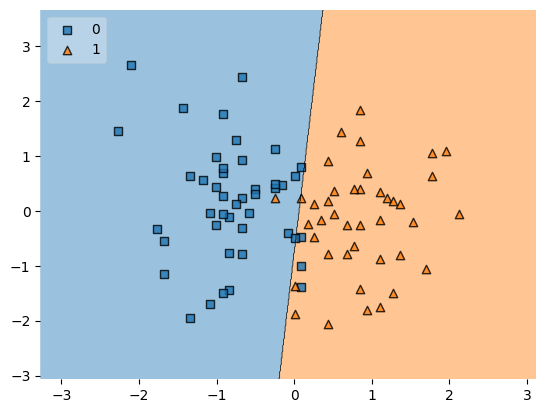

In [51]:
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2)

In [52]:
import pickle

In [55]:
pickle.dump(clf,open('model.pkl','wb'))